# Tutorial 1 — Characterising sensor measurements

## 1. Problem / context

A production line records plate thickness (µm) from an inline sensor. Process engineering wants a first characterisation of `sensor_thickness.csv`:

- What thickness is typical, and how much does it spread?
- What is the shape of the distribution?
- Do lines A and B look different as a description of this sample?
- Does thickness appear to drift with production order?

No hypothesis test yet. Today we **describe** the observed measurements. Brooks Chapter 1 gives the full definitions of population, sample, and the numerical summaries.

The file is `data/sensor_thickness.csv`.

## 2. What we will compute

- The **sample mean** $\bar{x}$ and **median** summarise the centre of the observed plates.
- The **sample standard deviation** $s$ uses $n-1$ because these plates are treated as a sample from a larger process, not as the entire population of plates that will ever be produced:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i-\bar{x})^2.
$$

  NumPy's default `np.std(x)` divides by $n$. Use that divisor only when you genuinely have a complete population. In this tutorial the data are a sample, so we use `ddof=1`.
- Quartiles $Q_1$, $Q_2$, $Q_3$ and the **IQR** $Q_3-Q_1$ describe the middle half of the data. Pandas `quantile` uses **linear interpolation** by default (Hyndman–Fan type 7). A hand calculation that uses a different quartile rule can differ by a few tenths of a micrometre; that is a convention, not an error.
- The **$1.5\times\mathrm{IQR}$ fence** flags *potential* outliers. It is not an automatic deletion rule: a point outside the fence may be a sensor glitch, or a genuine unusual plate.
- A **histogram** and **boxplot** show shape. A **run plot** of thickness against `sample_id` is the plot that can reveal drift.

## 3. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

candidates = [Path("data"), Path("../data"), Path.cwd() / "data"]
DATA = next(p for p in candidates if p.exists())

df = pd.read_csv(DATA / "sensor_thickness.csv")[["sample_id", "line", "thickness_um"]]
df.head()


,sample_id,line,thickness_um
0,1,A,246.669
1,2,A,251.010
2,3,A,242.035
3,4,A,255.862
4,5,A,252.681


Overall sample summaries:


In [2]:
x = df["thickness_um"]
summary = pd.Series(
    {
        "n": x.size,
        "mean": x.mean(),
        "median": x.median(),
        "std_sample": x.std(ddof=1),
        "std_numpy_default": np.std(x),
        "std_numpy_ddof1": np.std(x, ddof=1),
        "q1": x.quantile(0.25),
        "q3": x.quantile(0.75),
    }
)
summary["iqr"] = summary["q3"] - summary["q1"]
summary


n                    180.000000
mean                 250.830356
median               250.577000
std_sample             4.809218
std_numpy_default      4.795841
std_numpy_ddof1        4.809218
q1                   247.336750
q3                   253.974250
iqr                    6.637500
dtype: float64

Groupwise summary for the two production lines:


In [3]:
def iqr(s):
    return s.quantile(0.75) - s.quantile(0.25)

by_line = (
    df.groupby("line")["thickness_um"]
    .agg(n="size", mean="mean", median="median", std_sample="std", iqr=iqr)
)
by_line


,n,mean,median,std_sample,iqr
line,,,,,
A,90,250.422144,249.6860,4.161238,5.58125
B,90,251.238567,250.8615,5.372533,7.98700


Pandas `std` already uses `ddof=1`.


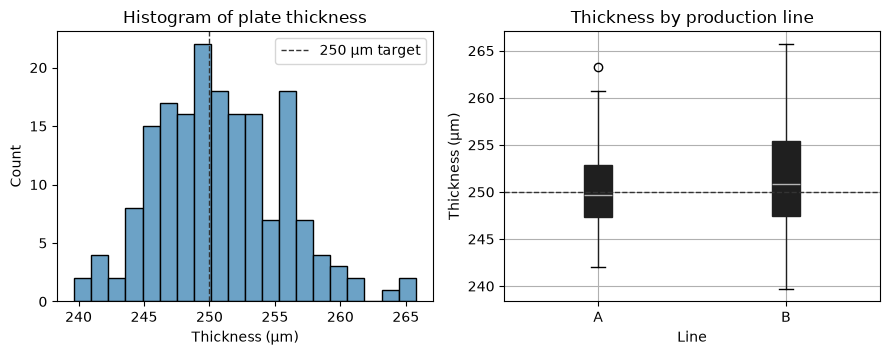

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].hist(x, bins=20, edgecolor="black", color="#6CA2C6")
axes[0].axvline(250, color="0.2", linestyle="--", linewidth=1, label="250 µm target")
axes[0].set_xlabel("Thickness (µm)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of plate thickness")
axes[0].legend()

df.boxplot(column="thickness_um", by="line", ax=axes[1], patch_artist=True)
axes[1].axhline(250, color="0.2", linestyle="--", linewidth=1)
axes[1].set_title("Thickness by production line")
axes[1].set_xlabel("Line")
axes[1].set_ylabel("Thickness (µm)")
plt.suptitle("")
plt.tight_layout()
plt.show()


Run plot against production order:


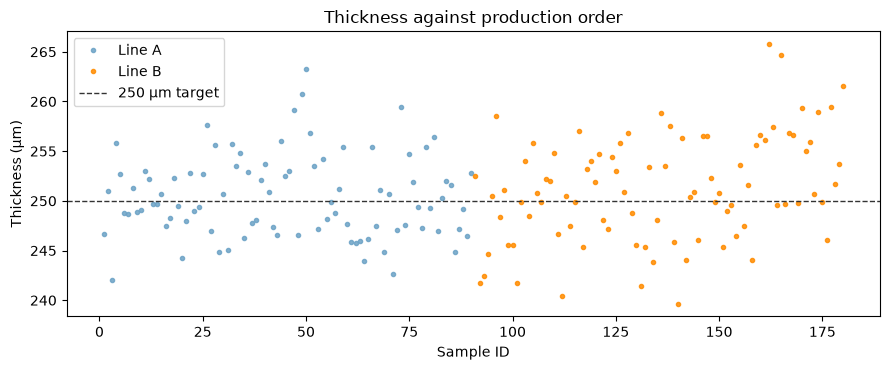

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
for line, color in [("A", "#6CA2C6"), ("B", "#FF8C00")]:
    part = df[df["line"] == line]
    ax.plot(
        part["sample_id"],
        part["thickness_um"],
        ".",
        color=color,
        label=f"Line {line}",
        alpha=0.85,
    )
ax.axhline(250, color="0.2", linestyle="--", linewidth=1, label="250 µm target")
ax.set_xlabel("Sample ID")
ax.set_ylabel("Thickness (µm)")
ax.set_title("Thickness against production order")
ax.legend()
plt.tight_layout()
plt.show()


Potential outliers from the $1.5\times\mathrm{IQR}$ rule (overall sample):


In [6]:
q1, q3 = x.quantile(0.25), x.quantile(0.75)
iqr_all = q3 - q1
low, high = q1 - 1.5 * iqr_all, q3 + 1.5 * iqr_all
n_out = int(((x < low) | (x > high)).sum())
print(f"Fences: [{low:.2f}, {high:.2f}] µm")
print(f"Potential outliers: {n_out} of {x.size}")


Fences: [237.38, 263.93] µm
Potential outliers: 2 of 180


Pause: from the run plot alone, would you describe a *clear* drift, a *hint* of later samples sitting higher, or *no* visible time pattern? Stay with what the plot shows.

## 4. Interpretation

The histogram is the place to talk about shape: unimodal or not, roughly symmetric or skewed, and whether 250 µm is a plausible centre for this sample. The boxplots compare the two lines **descriptively**. A visible shift in the boxes is a feature of *these* 180 plates; it is not evidence that line is a process factor, and it is not a test of a mean difference.

The run plot is the plot that can show drift. Later sample IDs may sit a little higher than the early ones. That is still a description of the observed series. We do not conclude that the process changed, and we do not delete points that fall outside the IQR fences without an engineering reason.

The two standard deviations in the overall table are a software reminder: pandas and `np.std(..., ddof=1)` agree; `np.std(x)` without `ddof` is slightly smaller because it divides by $n$.

## 5. Common mistakes / things to notice

- Using `np.std(x)` on a sample and calling it $s$.
- Treating a visible boxplot difference as a proven process change. A two-line inferential comparison belongs in **Session 08**. Session 09 is for ANOVA with more than two groups.
- Deleting every point outside the $1.5\times\mathrm{IQR}$ fence without asking why it is there.
- Expecting hand-calculated quartiles to match pandas to the last digit.
- Claiming that a large sample makes the *measurements* normal. A large sample makes the histogram closer to the **population** shape, which need not be normal. The CLT is about $\bar{X}$, not about $X$ (Session 05).
- Forgetting units on axes.

**Conclusion:** These 180 plates are centred near the 250 µm target, with a sample SD of a few micrometres. Lines A and B can be summarised separately, and the run plot can be inspected for order effects, but neither comparison is an inference about the process. Potential IQR outliers stay in the data until there is a reason to treat them as errors.
